# Topology-Aware Language Model Trainer

This code implements a topology-aware trainer for causal language models (CLMs). It aims to improve the efficiency and generalization ability of CLMs by encouraging sparse and focused activation patterns within the model.

## Key Features

* **Topology-Guided Training:**  The trainer incorporates topology-related metrics (attention entropy, sparsity, FFN density) into the training process.
* **Adaptive Thresholding:** Dynamically adjusts the threshold for determining important connections and activations over time.
* **Gradient Modification:**  Modifies gradients during backpropagation to guide the model towards the desired topology.
* **Comprehensive Metrics:** Tracks and visualizes key topology metrics to monitor training progress.
* **Checkpointing:** Saves and loads model checkpoints, including topology statistics.

LlamaModel is using LlamaSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


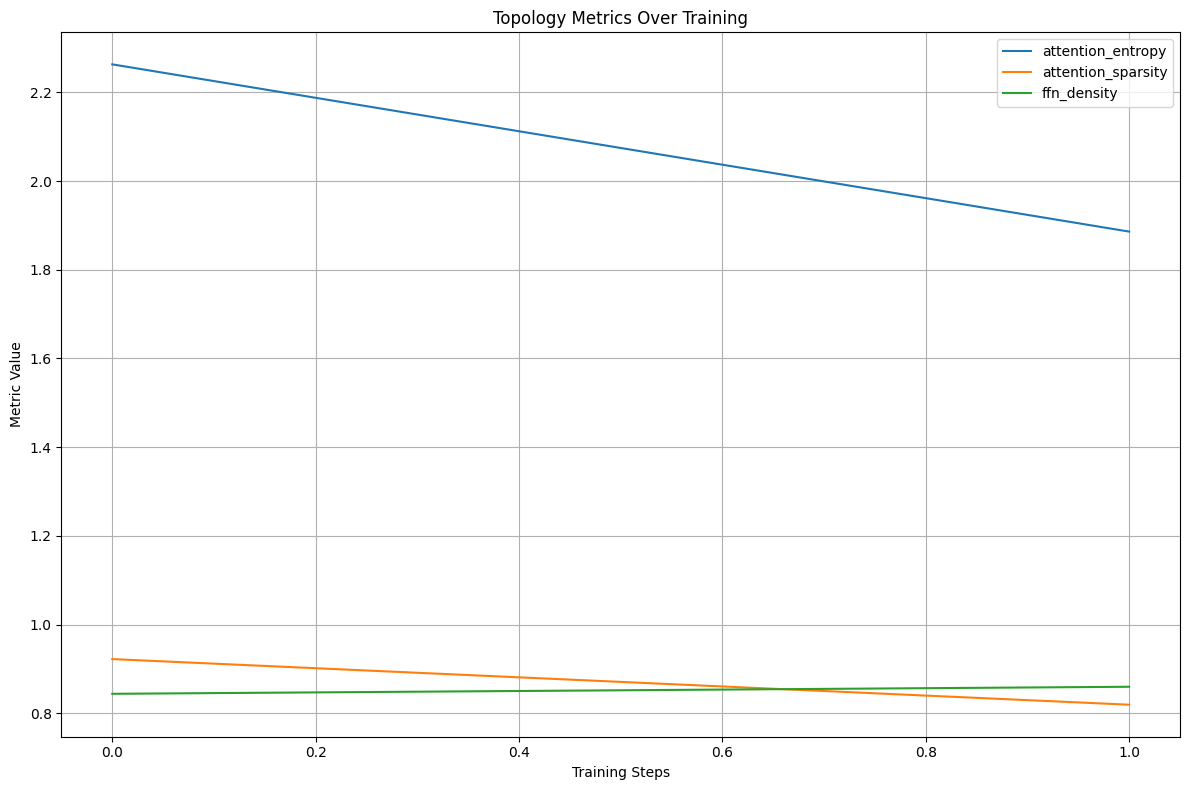

Checkpoint saved at ./checkpoints/checkpoint_epoch_1.pt


In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass

# Configuration class
@dataclass
class TopologyConfig:
    initial_threshold: float = 0.15
    decay_rate: float = 0.98
    entropy_weight: float = 0.12
    sparsity_weight: float = 0.06
    density_weight: float = 0.04
    learning_rate: float = 5e-5
    checkpoint_dir: str = "./checkpoints"
    device: str = "cuda"

class TopologyAwareTrainer:
    def __init__(
        self,
        checkpoint: str,
        model: AutoModelForCausalLM,
        tokenizer: AutoTokenizer,
        config: TopologyConfig
    ):
        self.checkpoint = checkpoint
        self.model = model
        self.tokenizer = tokenizer
        self.device = config.device
        self.optimizer = Adam(model.parameters(), lr=config.learning_rate)
        self.config = config
        self.topology_threshold = config.initial_threshold
        self.topology_stats: Dict[str, List[float]] = {
            "attention_entropy": [],
            "attention_sparsity": [],
            "ffn_density": [],
            "topology_loss": [],
            "prediction_loss": [],
            "total_loss": []
        }
        self.global_step = 0

    def initialize_metrics(self):
        """Initialize topology metrics with the model's initial state."""
        with torch.no_grad():
            initial_outputs = self.model(
                input_ids=torch.randint(0, self.model.config.vocab_size, (1, 10)).to(self.device),
                output_attentions=True,
                output_hidden_states=True
            )
            initial_metrics = self.compute_topology_metrics({
                "attention_patterns": initial_outputs.attentions[-1],
                "ffn_outputs": initial_outputs.hidden_states[-1]
            })
            for key, value in initial_metrics.items():
                self.topology_stats[key].append(value)

    def update_topology_threshold(self) -> None:
        """Update topology threshold with decay."""
        self.topology_threshold *= self.config.decay_rate

    def compute_topology_metrics(self, layer_outputs: Dict[str, torch.Tensor]) -> Dict[str, float]:
        """Compute topology-related metrics."""
        metrics = {}

        attention = layer_outputs.get("attention_patterns")
        if attention is not None and attention.numel() > 0:
            attention_probs = F.softmax(attention, dim=-1)
            entropy = -(attention_probs * torch.log(attention_probs + 1e-9)).sum(-1).mean()
            metrics["attention_entropy"] = entropy.item()
            sparsity = (attention_probs < self.topology_threshold).float().mean()
            metrics["attention_sparsity"] = sparsity.item()

        ffn = layer_outputs.get("ffn_outputs")
        if ffn is not None and ffn.numel() > 0:
            activation_density = (torch.abs(ffn) > self.topology_threshold).float().mean()
            metrics["ffn_density"] = activation_density.item()

        return metrics

    def calculate_topology_loss(self, metrics: Dict[str, float]) -> float:
        """Calculate topology regularization loss."""
        attention_entropy_loss = 1.0 - metrics.get("attention_entropy", 0)
        sparsity_loss = metrics.get("attention_sparsity", 0)
        ffn_density_loss = metrics.get("ffn_density", 0)

        return (self.config.entropy_weight * attention_entropy_loss +
                self.config.sparsity_weight * sparsity_loss +
                self.config.density_weight * ffn_density_loss)

    def topology_guided_backward(
        self,
        loss: torch.Tensor,
        layer_outputs: Dict[str, torch.Tensor]
    ) -> None:
        """Perform topology-aware backward pass."""
        loss.backward()

        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if param.grad is not None:
                    if "attention" in name:
                        mask = torch.abs(param) > self.topology_threshold
                        param.grad *= mask.float()
                    elif "ffn" in name:
                        grad_scale = torch.exp(-torch.abs(param))
                        param.grad *= grad_scale

    def train_step(
        self,
        input_ids: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None
    ) -> Dict[str, float]:
        """Perform a single training step with topology awareness."""
        self.model.train()
        self.optimizer.zero_grad()

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids,
            output_attentions=True,
            output_hidden_states=True
        )

        layer_outputs = {
            "attention_patterns": outputs.attentions[-1] if outputs.attentions else torch.zeros(1),
            "ffn_outputs": outputs.hidden_states[-1] if outputs.hidden_states else torch.zeros(1)
        }

        loss = outputs.loss
        metrics = self.compute_topology_metrics(layer_outputs)

        for key, value in metrics.items():
            self.topology_stats[key].append(value)

        topo_loss = self.calculate_topology_loss(metrics)
        total_loss = loss + topo_loss
        self.topology_guided_backward(total_loss, layer_outputs)
        self.optimizer.step()

        self.global_step += 1
        metrics["prediction_loss"] = loss.item()
        metrics["topology_loss"] = topo_loss
        metrics["total_loss"] = total_loss.item()
        return metrics

    def train_epoch(self, train_data: List[str], batch_size: int = 4) -> Dict[str, float]:
        """Train for one epoch."""
        self.initialize_metrics()
        epoch_metrics: Dict[str, List[float]] = {}
        encodings = self.tokenizer(
            train_data,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(self.device)

        for i in range(0, len(train_data), batch_size):
            batch_input_ids = encodings.input_ids[i:i + batch_size]
            batch_attention_mask = encodings.attention_mask[i:i + batch_size]

            metrics = self.train_step(batch_input_ids, batch_attention_mask)
            for key, value in metrics.items():
                if key not in epoch_metrics:
                    epoch_metrics[key] = []
                epoch_metrics[key].append(value)

        return {k: np.mean(v) for k, v in epoch_metrics.items()}

    def plot_metrics(self):
        """Visualize collected topology metrics over training steps."""
        if not any(len(v) > 0 for v in self.topology_stats.values()):
            print("No metrics available to plot.")
            return

        max_length = max(len(v) for v in self.topology_stats.values())
        x_values = range(max_length)

        plt.figure(figsize=(12, 8))
        for metric_name, metric_values in self.topology_stats.items():
            if len(metric_values) > 0:
                plt.plot(range(len(metric_values)), metric_values, label=metric_name)

        plt.xlabel("Training Steps")
        plt.ylabel("Metric Value")
        plt.title("Topology Metrics Over Training")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def save_checkpoint(self, epoch: int) -> None:
        """Save model checkpoint."""
        os.makedirs(self.config.checkpoint_dir, exist_ok=True)
        checkpoint_path = os.path.join(self.config.checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save(self.model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")

# Configuration
config = TopologyConfig()
checkpoint = "HuggingFaceTB/SmolLM2-135M"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': tokenizer.eos_token})

model = AutoModelForCausalLM.from_pretrained(checkpoint).to(device)
model.resize_token_embeddings(len(tokenizer))

# Initialize the trainer
trainer = TopologyAwareTrainer(
    checkpoint=checkpoint,
    model=model,
    tokenizer=tokenizer,
    config=config
)

# Sample training data
train_data = ["The future of AI is bright.", "Quantum computing is on the horizon.", "Data privacy is crucial."]
metrics = trainer.train_epoch(train_data)
trainer.plot_metrics()
trainer.save_checkpoint(epoch=1)